# 09 — Calculate Foreign Exchange (FX) delta

Calculate currency sensitivity against INR, including FX created by foreign assets.

Foreign Exchange (FX) delta includes dedicated FX products and USD or EUR positions held by other desks.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

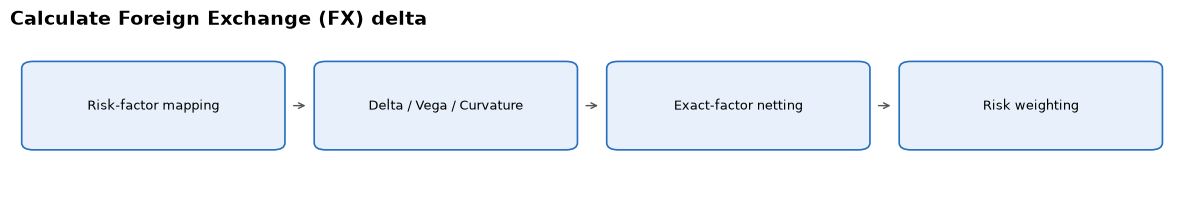

In [2]:
draw_flow(['Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting', 'Risk weighting'],'Calculate Foreign Exchange (FX) delta',wrap_after=4)

Apply a 1% relative currency-rate bump, reprice in INR, and divide the value change by 0.01.

$$s_k=\frac{V(FX_k\times1.01)-V(FX_k)}{0.01}$$

In [3]:
from frtb_engine.parameters import risk_weight
delta=pd.read_csv(RUN/'03_delta_trade_level.csv')
view=delta[delta.risk_class=='FX'].copy()
view['value_change_for_bump_inr']=view.shocked_value_inr-view.base_value_inr
view['bump_unit']=np.where(view.relative,'1% relative move','1 basis point')
view['applicable_risk_weight']=view.apply(lambda row:risk_weight(row.to_dict(),'DELTA'),axis=1)
view['tenor_display']=view.apply(
    lambda row:f"{row.tenor:g} years" if pd.notna(row.tenor)
    else 'Not applicable for this risk factor',axis=1)
columns=['trade_id','instrument_type','currency','risk_class','bucket','risk_factor_id','tenor_display',
         'bump_unit','applicable_risk_weight','base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity']
shown=crore_table(view[columns],['base_value_inr','shocked_value_inr','value_change_for_bump_inr','raw_sensitivity'])
display_sample(percent_columns(shown,['applicable_risk_weight']),25)
print('The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.')
example=view.iloc[0]
print(f"Worked trade: {example.trade_id} | factor: {example.risk_factor_id}")
print(f"Base value: INR {example.base_value_inr/INR_CRORE:,.4f} crore")
print(f"Shocked value: INR {example.shocked_value_inr/INR_CRORE:,.4f} crore")
print(f"Value change for bump: INR {example.value_change_for_bump_inr:,.2f}")
print(f"Sensitivity = value change / bump = INR {example.raw_sensitivity:,.2f} per unit change")

Displayed rows: first 25 of 27 observations, in table order.


,trade_id,instrument_type,currency,risk_class,bucket,risk_factor_id,tenor_display,bump_unit,Applicable Risk Weight (%),Base Value (INR crore),Shocked Value (INR crore),Value Change For Bump (INR crore),Raw Sensitivity (INR crore per unit change)
4,R04,BOND,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,17.2911,17.4640,0.1729,17.2911
6,R05,BOND,EUR,FX,EUR,EURINR,Not applicable for this risk factor,1% relative move,15.0000,16.4608,16.6254,0.1646,16.4608
9,R07,IRS,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,0.0000,0.0000,0.0000,0.0000
13,R10,SWAPTION,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,1.0027,1.0128,0.0100,1.0027
19,R12,XCCY_BASIS_SWAP,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,0.0330,0.0333,0.0003,0.0330
26,C02,CORPORATE_BOND,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,12.4621,12.5867,0.1246,12.4621
29,C03,CORPORATE_BOND,EUR,FX,EUR,EURINR,Not applicable for this risk factor,1% relative move,15.0000,11.2113,11.3234,0.1121,11.2113
38,C06,CDS,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,-0.0568,-0.0573,-0.0006,-0.0568
41,C07,CREDIT_OPTION,USD,FX,USD,USDINR,Not applicable for this risk factor,1% relative move,15.0000,0.0830,0.0838,0.0008,0.0830
46,C08,CALLABLE_BOND,EUR,FX,EUR,EURINR,Not applicable for this risk factor,1% relative move,15.0000,8.1260,8.2072,0.0813,8.1260


The risk weight is shown for reference. Formal weighting happens after exact-factor netting in Notebook 18.
Worked trade: R04 | factor: USDINR
Base value: INR 17.2911 crore
Shocked value: INR 17.4640 crore
Value change for bump: INR 1,729,113.02
Sensitivity = value change / bump = INR 172,911,302.14 per unit change


The visual below uses the calculated rows shown above.

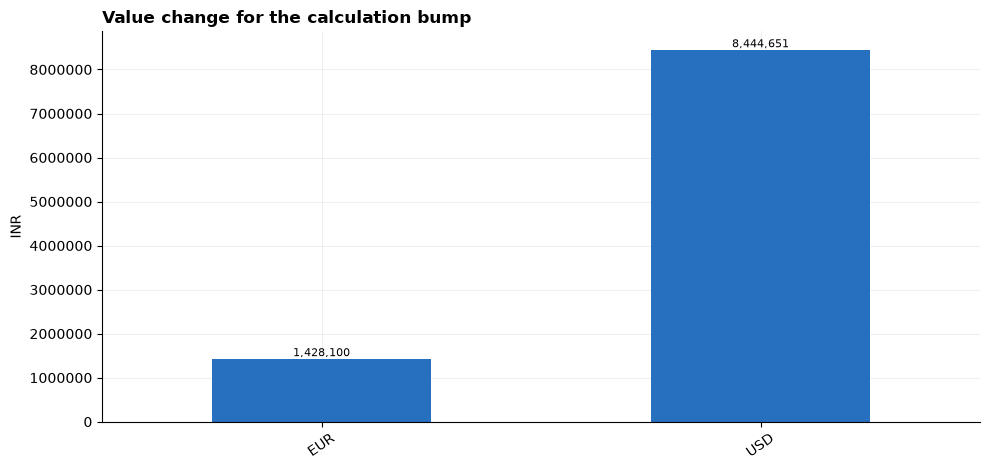

In [4]:
bar_inr(view.groupby('bucket')['value_change_for_bump_inr'].sum(),'Value change for the calculation bump')

The result shows both direct FX trading and incidental currency risk.